In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
from torchmetrics import F1Score

import librosa
import torchaudio

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from pathlib import Path
import os
import gc
from collections import defaultdict
import random
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [3]:
SEED = 1001
SR = 22050
AUDIO_SAMPLES = SR * 30  # 30s audio
NOISE_SAMPLES = SR * 5   # 5s noise audio
GENRES = {
    'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4,
    'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9
}
STEMS = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
ROOT_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

In [4]:
class MMDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.samples = []
        genres_stems = self.root_dir / "genres_stems"

        for genre, label in GENRES.items():    
            for song_dir in (genres_stems / genre).iterdir():
                if song_dir.is_dir():
                    self.samples.append((song_dir, label))

        noise_dir = self.root_dir / "ESC-50-master" / "audio"
        self.noise_files = list(noise_dir.glob("*.wav"))
        
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):        
        song_dir, label = self.samples[idx]
        waveform = self.load_song(song_dir)
        
        return waveform, label

    def load_song(self, song_dir):
        stems_audio = []
    
        for stem in STEMS:
            waveform, _ = librosa.load(song_dir / stem)
            if waveform.shape[0] < AUDIO_SAMPLES:
                waveform = np.pad(waveform, pad_width=(0, AUDIO_SAMPLES-waveform.shape[0]))
            else:
                # removing the initial extra samples
                waveform = waveform[waveform.shape[0]-AUDIO_SAMPLES : ]
            stems_audio.append(waveform)

        # stack all stems vertically
        stems_stack = np.vstack(stems_audio)
        # mix the stems by averaging them to form an audio
        audio = stems_stack.mean(axis=0)
        return audio
    
    def add_noise(self, waveform):
        n = 2
        noise_files = random.sample(self.noise_files, n)
        slots = random.sample(range(AUDIO_SAMPLES // NOISE_SAMPLES), n)
    
        for nf, slot in zip(noise_files, slots):
            noise, _ = librosa.load(nf)

            start = slot * NOISE_SAMPLES
            end = start + NOISE_SAMPLES
            
            signal_rms = np.sqrt(np.mean(waveform[start:end] ** 2))
            noise_rms = np.sqrt(np.mean(noise[:NOISE_SAMPLES] ** 2))

            # varying intensities of noise
            # sound to noise ratio (SNR)
            snr_db = random.randint(5, 10)
            
            snr_linear = 10 ** (snr_db / 20)
            noise_scale = signal_rms / (snr_linear * noise_rms + 1e-8)
            
            waveform[start:end] += noise_scale * noise[:NOISE_SAMPLES]
            
        return waveform


In [5]:
# class WindowDataset(Dataset):
#     def __init__(self, dataset, window_size=3, overlap=0.0):
#         self.dataset = dataset
#         self.window_size = window_size
#         self.overlap = overlap
        
#         # Calculate samples directly (avoid integer truncation)
#         self.window_samples = int(window_size * SR)
#         self.stride_samples = int(window_size * SR * (1 - overlap))  # Direct calculation
        
#         # Pre-compute the total number of windows across all samples
#         self.window_indices = []
#         for idx in range(len(self.dataset)):
#             sample, label = self.dataset[idx]

#             # simple arithmetic progression technique
#             # a_n = a + d*(n)
#             # put a_n=30, a=3, d=1.5 and you get num_windows: n+1
#             num_windows = (sample.shape[0] - self.window_samples) // self.stride_samples + 1
            
#             for window_idx in range(max(1, num_windows)):
#                 self.window_indices.append((idx, window_idx))
    
#     def __len__(self):
#         return len(self.window_indices)
    
#     def __getitem__(self, idx):
#         sample_idx, window_idx = self.window_indices[idx]
#         sample, label = self.dataset[sample_idx]
        
#         start = window_idx * self.stride_samples
#         end = start + self.window_samples
#         chunk = sample[start:end]
        
#         if chunk.dim() == 1:
#             chunk = chunk.unsqueeze(0)
        
#         return chunk, label

In [6]:
class WindowDataset(Dataset):
    def __init__(self, tensor_dataset, noise_dir=None, window_size=3, overlap=0.25, sr=SR, augment=False):
        """
        tensor_dataset: The TensorDataset containing (all_waveforms, all_labels)
        noise_dir: Path to ESC-50 audio folder (only needed if augment=True)
        """
        self.dataset = tensor_dataset
        self.sr = sr
        self.augment = augment
        
        # Calculate window parameters
        self.window_samples = int(window_size * sr)
        self.stride_samples = int(window_size * sr * (1 - overlap))
        
        # --- Pre-load Noise into RAM using Librosa ---
        self.noise_bank = []
        if self.augment and noise_dir:
            print(f"Pre-loading noise from {noise_dir} using Librosa...")
            noise_path = Path(noise_dir)
            
            # Iterate over wav files
            for f in list(noise_path.glob("*.wav")): 
                wav_numpy, _ = librosa.load(f, sr=self.sr)
                # Convert to Tensor immediately to save memory/conversion time later
                # Shape becomes [1, samples] to match typical PyTorch audio dims
                wav_tensor = torch.from_numpy(wav_numpy).float().unsqueeze(0)
                
                self.noise_bank.append(wav_tensor)
                
            print(f"Loaded {len(self.noise_bank)} noise tensors into RAM.")

        self.indices = []
        
        if len(self.dataset) > 0:
            example_waveform, _ = self.dataset[0] 
            # flexible handling if dataset returns [C, T] or [T]
            total_samples = example_waveform.shape[-1] 
            
            num_windows = (total_samples - self.window_samples) // self.stride_samples + 1
            
            for idx in range(len(self.dataset)):
                for win_i in range(int(num_windows)):
                    self.indices.append((idx, win_i))
        else:
            print("Warning: Provided dataset is empty.")

    def __len__(self):
        return len(self.indices)
        
    def _add_noise(self, waveform):
        if not self.noise_bank: return waveform

        noise = random.choice(self.noise_bank)
        
        # 2. Crop noise to fit window
        # Ensure noise is at least as long as window; if not, pad (rare for ESC-50 vs 3s)
        if noise.shape[-1] < self.window_samples:
            noise = torch.nn.functional.pad(noise, (0, self.window_samples - noise.shape[-1]))
        
        # Random start crop
        max_start = noise.shape[-1] - self.window_samples
        start = random.randint(0, max_start) if max_start > 0 else 0
        noise_crop = noise[..., start : start + self.window_samples]
        
        # 3. SNR Mixing (Pure Tensor Math - Very Fast)
        snr_db = random.uniform(5, 15)
        
        # Calculate RMS
        sig_rms = waveform.pow(2).mean().sqrt()
        noise_rms = noise_crop.pow(2).mean().sqrt()
        
        if noise_rms > 0:
            snr_linear = 10 ** (snr_db / 20.)
            scale = sig_rms / (snr_linear * noise_rms + 1e-8)
            return waveform + (noise_crop * scale)
        return waveform

    def _time_shift(self, waveform):
        # Shift audio left or right (Cyclic shift is fastest, or zero padding)
        shift_amt = int(random.uniform(-0.5, 0.5) * self.sr) # +/- 500ms
        return torch.roll(waveform, shift_amt, dims=-1)

    def __getitem__(self, idx):
        sample_idx, window_idx = self.indices[idx]
        
        # 1. Get full song from RAM (Fast)
        full_waveform, label = self.dataset[sample_idx]
        
        # 2. Slice window
        start = window_idx * self.stride_samples
        end = start + self.window_samples
        
        # Handle shape [1, L] or [L]
        if full_waveform.dim() == 1:
            chunk = full_waveform[start:end]
        else:
            chunk = full_waveform[:, start:end]

        # 3. Augment (Only if augment flag is on)
        if self.augment:
            # Probability to apply augmentations
            if random.random() < 0.5:
                chunk = self._add_noise(chunk)
            
            # Simple Time Shift (fastest "time" augmentation)
            if random.random() < 0.5:
                chunk = self._time_shift(chunk)
            
            # NOTE: Pitch/TimeStretch via torchaudio.sox_effects is powerful but 
            # can be unstable inside DataLoader multiprocessing depending on OS. 
            # If you need heavy Pitch Shift, uncomment below, but Noise+TimeShift is often enough.
            
            # if random.random() < 0.3:
            #     effects = [['pitch', str(random.randint(-200, 200))]]
            #     chunk, _ = torchaudio.sox_effects.apply_effects_tensor(chunk.unsqueeze(0), self.sr, effects)
            #     chunk = chunk.squeeze(0)

        # 4. Ensure shape is correct (channels, time)
        # If your model expects [1, 66150], ensure dimensions here
        if chunk.dim() == 1:
            chunk = chunk.unsqueeze(0)
            
        return chunk, label

In [7]:
dataset = MMDataset(ROOT_DIR)
n_samples = len(dataset)

sample_x, sample_y = dataset[0]

all_waveforms = torch.empty((n_samples, *sample_x.shape))
all_labels = torch.empty(n_samples, dtype=torch.long)

loader = DataLoader(
    dataset,
    batch_size=25,
    num_workers=4,
    prefetch_factor=2,
)

start_idx = 0
for xb, yb in tqdm(loader, desc="Loading data into RAM"):
    batch_size = xb.size(0)
    end_idx = start_idx + batch_size
    all_waveforms[start_idx:end_idx] = xb
    all_labels[start_idx:end_idx] = yb.long()
    start_idx = end_idx

Loading data into RAM: 100%|██████████| 40/40 [01:56<00:00,  2.92s/it]


In [8]:
# Split into train/val
train_idx, val_idx = train_test_split(
    np.arange(n_samples),
    test_size=0.2,
    shuffle=True,
    stratify=all_labels.numpy(),
    random_state=SEED
)

train_dataset = TensorDataset(all_waveforms[train_idx], all_labels[train_idx])
val_dataset = TensorDataset(all_waveforms[val_idx], all_labels[val_idx])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")

Train dataset size: 800
Val dataset size: 200


In [52]:
# Define path to noise
NOISE_DIR = Path(ROOT_DIR) / "ESC-50-master" / "audio"

print("Creating Training Window Dataset...")
splitted_train_data = WindowDataset(
    train_dataset,
    noise_dir=NOISE_DIR, 
    augment=True,
    window_size=3, 
    overlap=0.5
)

print("Creating Validation Window Dataset...")
splitted_val_data = WindowDataset(
    val_dataset,
    noise_dir=NOISE_DIR, 
    augment=True,
    window_size=3, 
    overlap=0.0
)

print(f"Train dataset size after splitting: {len(splitted_train_data)}")
print(f"Val dataset size after splitting: {len(splitted_val_data)}")

# Create DataLoaders with windowed datasets
train_loader = DataLoader(
    splitted_train_data,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    splitted_val_data,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

Creating Training Window Dataset...
Pre-loading noise from /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio using Librosa...
Loaded 2000 noise tensors into RAM.
Creating Validation Window Dataset...
Pre-loading noise from /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio using Librosa...
Loaded 2000 noise tensors into RAM.
Train dataset size after splitting: 15200
Val dataset size after splitting: 2000


In [10]:
# import gc

# # Cleanup
# del all_waveforms, all_labels
# gc.collect()

In [65]:
class AudioCRNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AudioCRNN, self).__init__()
        
        # --- 1. Convolutional Feature Extractor ---
        # Input shape: [Batch, 1, 128, 129]
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2) 
            # Output: [16, 64, 64] (Approx, Time dim 129 -> 64)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
            # Output: [32, 32, 32]
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
            # Output: [64, 16, 16]
        )
        
        # --- 2. Calculate LSTM Input Size ---
        # After 3 pooling layers of stride 2:
        # Freq: 128 -> 64 -> 32 -> 16
        # Time: 129 -> 64 -> 32 -> 16
        # Channels: 64
        # LSTM Input Size = Channels * Freq_Dim = 64 * 16 = 1024
        self.lstm_input_size = 16 * 16 
        self.hidden_size = 32
        self.num_layers = 2
        
        # --- 3. Recurrent Layer (LSTM) ---
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size, 
            hidden_size=self.hidden_size, 
            num_layers=self.num_layers, 
            batch_first=True,
            dropout=0.2
        )
        
        # --- 4. Classifier ---
        self.fc1 = nn.Linear(self.hidden_size, 20)
        self.fc2 = nn.Linear(20, num_classes)
        
    def forward(self, x):
        # x shape: [Batch, 1, 128, 129]
        
        # Apply CNN
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x) 
        # Shape is now: [Batch, 64, 16, 16] (Channels, Freq, Time)
        
        # Prepare for LSTM: (Batch, Time, Features)
        # We permute to bring Time to dimension 1: [Batch, Time, Channels, Freq]
        x = x.permute(0, 3, 1, 2) 
        # Shape: [Batch, 16, 64, 16]
        
        # Flatten Channels and Freq into a single feature vector
        batch_size, time_steps, C, F = x.size()
        x = x.reshape(batch_size, time_steps, C * F)
        # Shape: [Batch, 16, 1024]
        
        # Feed to LSTM
        lstm_out, _ = self.lstm(x)
        # Shape: [Batch, 16, 128]
        
        # Take the last time step for classification
        last_time_step = lstm_out[:, -1, :]
        
        # Fully Connected Layer
        out = self.fc2(self.fc1(last_time_step))
        
        return out

In [34]:
# import torch
# import torch.nn as nn
# import torch.nn.init as init

# class AudioCRNN(nn.Module):
#     def __init__(self, num_classes=10):
#         """
#         Args:
#             input_shape: tuple (channels, height, width) e.g., (1, 128, 129)
#             num_outputs: number of output classes
#         """
#         super(AudioCRNN, self).__init__()
        
#         channels, height, width = (1, 128, 129)
        
#         # Convolutional layers
#         self.conv1 = nn.Conv2d(channels, 32, kernel_size=3, stride=1, padding=1)
#         self.relu1 = nn.ReLU()
#         self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
#         self.relu2 = nn.ReLU()
#         self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Calculate dimensions after pooling
#         self.height_after_pool = height // 4
#         self.width_after_pool = width // 4
#         self.gru_input_size = 64 * self.height_after_pool
        
#         # Recurrent layers
#         self.gru1 = nn.GRU(self.gru_input_size, 128, batch_first=True)
#         self.dropout = nn.Dropout(0.7)
#         self.gru2 = nn.GRU(128, 96, batch_first=True)
        
#         # Output layer
#         self.fc = nn.Linear(96, num_classes)
        
#         # Initialize weights
#         self._initialize_weights()
    
#     def _initialize_weights(self):
#         """Initialize weights with lecun_uniform (similar to Keras)"""
#         for m in self.modules():
#             if isinstance(m, nn.Conv2d):
#                 init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
#                 if m.bias is not None:
#                     init.constant_(m.bias, 0)
#             elif isinstance(m, nn.GRU):
#                 for name, param in m.named_parameters():
#                     if 'weight' in name:
#                         init.kaiming_uniform_(param, mode='fan_in', nonlinearity='linear')
#                     elif 'bias' in name:
#                         init.constant_(param, 0)
#             elif isinstance(m, nn.Linear):
#                 init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
#                 if m.bias is not None:
#                     init.constant_(m.bias, 0)
    
#     def forward(self, x):
#         # x shape: [batch, channels, height, width] e.g., [32, 1, 128, 129]
        
#         # Convolutional layers
#         x = self.conv1(x)
#         x = self.relu1(x)
#         x = self.pool1(x)  # [32, 32, 64, 64]
        
#         x = self.conv2(x)
#         x = self.relu2(x)
#         x = self.pool2(x)  # [32, 64, 32, 32]
        
#         # Permute: (batch, channels, height, width) -> (batch, width, channels, height)
#         # Keras Permute(2, 1, 3) means (width, height, channels) in NHWC format
#         # In PyTorch NCHW, this translates to (batch, channels, height, width) -> (batch, width, channels, height)
#         x = x.permute(0, 3, 1, 2)  # [32, 32, 64, 32] -> (batch, width, channels, height)
        
#         # Reshape for GRU: (batch, width, channels * height)
#         batch_size = x.size(0)
#         seq_len = x.size(1)
#         x = x.reshape(batch_size, seq_len, -1)  # [32, 32, 2048]
        
#         # Recurrent layers
#         x, _ = self.gru1(x)  # [32, 32, 128]
#         x = self.dropout(x)
#         x, _ = self.gru2(x)  # [32, 32, 96]
        
#         # Take the last time step
#         x = x[:, -1, :]  # [32, 96]
        
#         # Output layer (no softmax - handled by CrossEntropyLoss)
#         x = self.fc(x)  # [32, num_outputs]
        
#         return x

In [72]:
import torch.optim.lr_scheduler as lr_scheduler

class LightningNetwork(pl.LightningModule):
    def __init__(self, network, num_classes=10, lr=5e-4, weight_decay=5e-3):
        super().__init__()
        self.network = network
        self.lr = lr
        self.weight_decay = weight_decay
        self.num_classes = num_classes
        self.loss_f = nn.CrossEntropyLoss()

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SR,
            n_fft=2048,
            hop_length=512,
            n_mels=128,
            f_min=0,
            f_max=SR//2,
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

        # Initialize F1 metrics
        self.val_f1 = F1Score(task='multiclass', num_classes=num_classes, average='macro')
        self.test_f1 = F1Score(task='multiclass', num_classes=num_classes, average='macro')

        # For logging
        self.train_loss_vector = []
        self.val_loss_vector = []
        self.accuracy_vector = []
        self.val_f1_vector = []
        self.test_f1_vector = []
    
    def forward(self, x):
        with torch.no_grad():
            x = self.mel_transform(x)
            x = self.amplitude_to_db(x)
        return self.network(x)

    def training_step(self, batch, batch_idx):
        xb, yb = batch        
        y_pred = self(xb)
        loss = self.loss_f(y_pred, yb)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xb, yb = batch
        logits = self(xb)
        loss = self.loss_f(logits, yb)
    
        preds = torch.argmax(logits, dim=1)
        correct = (preds == yb).sum().float()
        total = float(yb.size(0))
        
        # Update F1 metric
        self.val_f1.update(preds, yb)
    
        # Log loss with default 'mean' reduction
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True, sync_dist=True)
        
        # Log counts with 'sum' reduction
        self.log('val_correct', correct, on_step=False, on_epoch=True, prog_bar=False, sync_dist=True, reduce_fx='sum')
        self.log('val_total', total, on_step=False, on_epoch=True, prog_bar=False, sync_dist=True, reduce_fx='sum')
        
        return {'val_loss': loss, 'correct': correct, 'total': total}

    def on_validation_epoch_end(self):
        if self.trainer.is_global_zero:
            val_loss = self.trainer.callback_metrics.get("val_loss")
            val_correct = self.trainer.callback_metrics.get("val_correct")
            val_total = self.trainer.callback_metrics.get("val_total")
            
            if val_loss is not None:
                self.val_loss_vector.append(val_loss.item())
            
            if val_correct is not None and val_total is not None:
                val_acc = val_correct / val_total
                self.accuracy_vector.append(val_acc.item())
            
            # Compute and log macro F1 score
            val_f1_score = self.val_f1.compute()
            self.val_f1_vector.append(val_f1_score.item())
            self.log("val_f1_macro", val_f1_score, prog_bar=True)
            
            # Reset metric for next epoch
            self.val_f1.reset()
    
    def test_step(self, batch, batch_idx):
        xb, yb = batch
        outputs = self(xb)
        preds = torch.argmax(outputs, dim=1)
        correct = (preds == yb).sum().float()
        
        # Update F1 metric
        self.test_f1.update(preds, yb)
        
        self.log('test_correct', correct, sync_dist=True, reduce_fx='sum')
        self.log('test_total', float(yb.size(0)), sync_dist=True, reduce_fx='sum')
        
        return {'correct': correct, 'total': yb.size(0)}
    
    def on_test_epoch_end(self):
        # Compute and log test macro F1 score
        test_f1_score = self.test_f1.compute()
        self.test_f1_vector.append(test_f1_score.item())
        self.log("test_f1_macro", test_f1_score, prog_bar=True)
        
        # Optionally calculate test accuracy
        test_correct = self.trainer.callback_metrics.get("test_correct")
        test_total = self.trainer.callback_metrics.get("test_total")
        if test_correct is not None and test_total is not None:
            test_acc = test_correct / test_total
            self.log("test_acc", test_acc, prog_bar=True)
        
        # Reset metric
        self.test_f1.reset()
    
    def configure_optimizers(self):
        optimizer = optim.Adam(params=self.parameters(), lr=self.lr, 
                               weight_decay=self.weight_decay, amsgrad=True)
        
        # Option 1: ReduceLROnPlateau - reduces LR when validation loss plateaus
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,        # Reduce LR by half
            patience=3,        # Wait 3 epochs before reducing
            min_lr=1e-4       # Minimum learning rate
        )
        
        # Option 2: CosineAnnealingLR - smooth cosine decay (uncomment to use)
        # scheduler = lr_scheduler.CosineAnnealingLR(
        #     optimizer,
        #     T_max=30,  # Should match max_epochs
        #     eta_min=1e-7
        # )
        
        # Option 3: OneCycleLR - increases then decreases LR (uncomment to use)
        # scheduler = lr_scheduler.OneCycleLR(
        #     optimizer,
        #     max_lr=self.lr * 10,
        #     total_steps=self.trainer.estimated_stepping_batches,
        #     pct_start=0.3,
        #     anneal_strategy='cos'
        # )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss',  # Metric to monitor (for ReduceLROnPlateau)
                'interval': 'epoch',
                'frequency': 1
            }
        }
    
    def on_train_epoch_end(self):
        if self.trainer.is_global_zero:
            train_loss = self.trainer.callback_metrics.get('train_loss')
            if train_loss is not None:
                self.train_loss_vector.append(train_loss.item())
            
            # Log current learning rate
            current_lr = self.trainer.optimizers[0].param_groups[0]['lr']
            self.log('lr', current_lr, prog_bar=True)



In [71]:

# Hyperparameters
# one good option (lr=1e-3, wd=1e-2)
# 1e-3 < lr < 1e-4
# 1e-2 < wd < 1e-4
epochs = 15
lr = 5e-4
weight_decay = 5e-3

pl.seed_everything(SEED, workers=True)

# Initialize model
network = AudioCRNN(num_classes=10)
model = LightningNetwork(network=network, num_classes=10, lr=lr, weight_decay=weight_decay)

# Checkpoint callback to save best model based on validation loss
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    filename='best-model-{epoch:02d}-{val_loss:.4f}'
)

# Early stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    verbose=True
)

# Initialize trainer
trainer = pl.Trainer(
    max_epochs=epochs,
    callbacks=[checkpoint_callback, early_stopping_callback],
    deterministic=True,
    logger=False,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

# Train the model
trainer.fit(model, train_loader, val_loader)

# Cleanup to prevent hanging
import gc
gc.collect()
torch.cuda.empty_cache()

if trainer.strategy.launcher is not None:
    trainer.strategy.launcher.kill_processes()


Seed set to 1001
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network         │ AudioCRNN         │ 50.1 K │ train │     0 │
│ 1 │ loss_f          │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ mel_transform   │ MelSpectrogram    │      0 │ train │     0 │
│ 3 │ amplitude_to_db │ AmplitudeToDB     │      0 │ train │     0 │
│ 4 │ val_f1          │ MulticlassF1Score │      0 │ train │     0 │
│ 5 │ test_f1         │ MulticlassF1Score │      0 │ train │     0 │
└───┴─────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 50.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 1.436
Metric val_loss improved by 0.267 >= min_delta = 0.0. New best score: 1.169
Metric val_loss improved by 0.100 >= min_delta = 0.0. New best score: 1.068
Metric val_loss improved by 0.071 >= min_delta = 0.0. New best score: 0.998
Metric val_loss improved by 0.048 >= min_delta = 0.0. New best score: 0.949
Metric val_loss improved by 0.030 >= min_delta = 0.0. New best score: 0.919
Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 0.892
Metric val_loss improved by 0.055 >= min_delta = 0.0. New best score: 0.837
Metric val_loss improved by 0.023 >= min_delta = 0.0. New best score: 0.813
Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 0.798
`Trainer.fit` stopped: `max_epochs=15` reached.


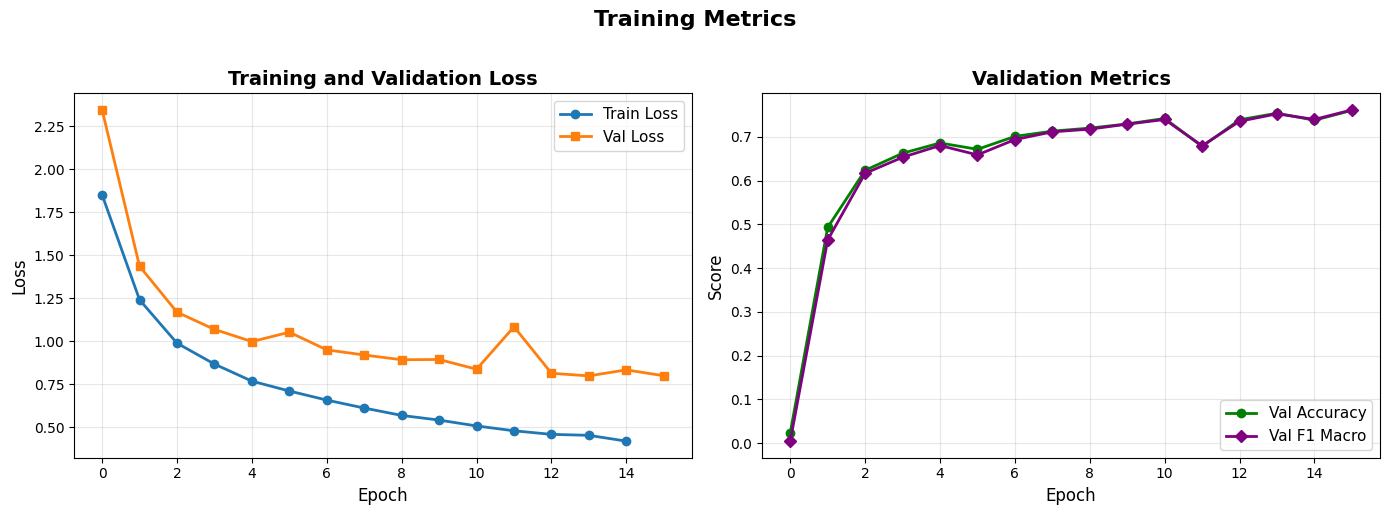


Final Metrics:
Train Loss: 0.4184
Val Loss: 0.7987

Best Metrics:
Best Val Accuracy: 0.7605 (Epoch 15)
Best Val F1 Score: 0.7616 (Epoch 15)


In [73]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Loss
axes[0].plot(model.train_loss_vector, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(model.val_loss_vector, label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation Accuracy and F1 Score
axes[1].plot(model.accuracy_vector, label='Val Accuracy', marker='o', 
             linewidth=2, color='green')
axes[1].plot(model.val_f1_vector, label='Val F1 Macro', marker='D', 
             linewidth=2, color='purple')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Validation Metrics', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Training Metrics', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Metrics:")
print(f"Train Loss: {model.train_loss_vector[-1]:.4f}")
print(f"Val Loss: {model.val_loss_vector[-1]:.4f}")
print(f"\nBest Metrics:")
print(f"Best Val Accuracy: {max(model.accuracy_vector):.4f} (Epoch {model.accuracy_vector.index(max(model.accuracy_vector))})")
print(f"Best Val F1 Score: {max(model.val_f1_vector):.4f} (Epoch {model.val_f1_vector.index(max(model.val_f1_vector))})")


In [40]:
# Load best model
best_model_path = checkpoint_callback.best_model_path
model = LightningNetwork.load_from_checkpoint(
    best_model_path,
    network=AudioCRNN(num_classes=10),
    lr=lr,
    weight_decay=weight_decay
)
print(f"Loaded best model with Val loss: {checkpoint_callback.best_model_score:.3f}")

Loaded best model with Val loss: 0.819


In [41]:
class TestDataset(Dataset):
    def __init__(self, audio_dir, window_size=3, overlap=0.5, sr=22050):
        self.sr = sr
        self.window_samples = int(window_size * sr)
        self.stride_samples = int(window_size * sr * (1 - overlap))
        
        self.audio_files = sorted(list(Path(audio_dir).glob('*.wav')))
        self.metadata = []  # Stores (file_idx, start_sample) for every window
        self.file_cache = {} # Simple RAM cache

        print("Indexing test files...")
        for file_idx, file_path in enumerate(self.audio_files):
            # We need the exact duration to calculate windows
            # librosa.get_duration is fast (reads header only)
            duration = librosa.get_duration(path=file_path)
            total_samples = int(duration * sr)
            
            # Calculate start points for every window in this file
            num_windows = int((total_samples - self.window_samples) / self.stride_samples) + 1
            
            for i in range(max(1, num_windows)):
                start = i * self.stride_samples
                self.metadata.append((file_idx, start))
                
        print(f"Created {len(self.metadata)} windows from {len(self.audio_files)} files.")

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        file_idx, start = self.metadata[idx]
        file_path = self.audio_files[file_idx]

        # 1. Load Audio (with caching)
        if file_idx not in self.file_cache:
            # Load full file once
            wav, _ = librosa.load(file_path, sr=self.sr, mono=True)
            self.file_cache[file_idx] = torch.from_numpy(wav).float()
            
        full_waveform = self.file_cache[file_idx]

        # 2. Slice Window
        end = start + self.window_samples
        chunk = full_waveform[start:end]

        if chunk.shape[0] < self.window_samples:
            chunk = torch.nn.functional.pad(chunk, (0, self.window_samples - chunk.shape[0]))
        
        # 4. Ensure shape [1, Time]
        if chunk.dim() == 1:
            chunk = chunk.unsqueeze(0)

        return chunk, file_idx

In [47]:
# 1. Setup
# IMPORTANT: window_size MUST match your training (3 seconds)
test_dataset = TestDataset(
    audio_dir=ROOT_DIR + "/mashups", 
    window_size=3,
    overlap=0.0
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Dictionary to store probabilities for each file
# file_idx -> list of probability tensors
file_probs = defaultdict(list)

print("Starting Prediction...")
with torch.no_grad():
    for chunks, file_indices in tqdm(test_loader):
        chunks = chunks.to(device)
        logits = model(chunks)
        
        # Get Probabilities (Softmax)
        # We use Softmax because averaging probabilities is better than averaging hard labels
        probs = F.softmax(logits, dim=1).cpu().numpy()
        
        # Store results grouped by file_idx
        for prob, f_idx in zip(probs, file_indices):
            file_probs[f_idx.item()].append(prob)

# 3. Aggregation (Soft Voting)
results = []
id_to_genre = {v: k for k, v in GENRES.items()}

for i, file_idx in enumerate(sorted(file_probs.keys()), start=1):
    # Stack all predictions for this song: Shape [Num_Windows, 10]
    all_window_probs = np.vstack(file_probs[file_idx])
    
    # AVERAGE the probabilities across all windows
    avg_probs = np.mean(all_window_probs, axis=0)
    
    # Get the class with the highest average probability
    pred_class_idx = np.argmax(avg_probs)
    confidence = avg_probs[pred_class_idx]
    
    filename = test_dataset.audio_files[file_idx].name
    
    results.append({
        "id": f"{i:04d}",
        "filename": filename,
        "genre": id_to_genre[pred_class_idx],
        "confidence": confidence
    })
    
    # print(f"File: {filename} -> {genres[pred_class_idx]} ({confidence:.2%})")

Indexing test files...
Created 27534 windows from 3020 files.
Starting Prediction...


100%|██████████| 431/431 [00:12<00:00, 34.50it/s]


In [48]:
df_results = pd.DataFrame(results)
print(df_results.head(10))

# Save updated results
df_results[['id', 'genre']].to_csv('submission.csv', index=False)
print(f"\nUpdated predictions saved to 'submission.csv'")

     id      filename   genre  confidence
0  0001  song0001.wav     pop    0.912698
1  0002  song0002.wav  hiphop    0.366736
2  0003  song0003.wav     pop    0.466562
3  0004  song0004.wav  hiphop    0.492954
4  0005  song0005.wav   blues    0.699827
5  0006  song0006.wav     pop    0.980841
6  0007  song0007.wav  hiphop    0.662234
7  0008  song0008.wav     pop    0.965080
8  0009  song0009.wav     pop    0.867353
9  0010  song0010.wav  hiphop    0.478928

Updated predictions saved to 'submission.csv'


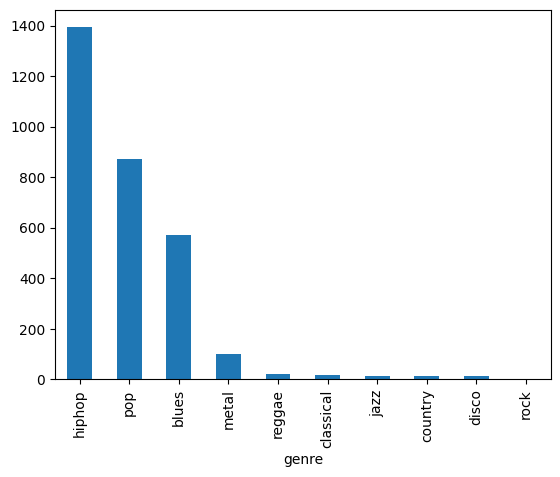

In [50]:
counts = df_results['genre'].value_counts()
counts.plot(kind='bar')
plt.show()

In [44]:
from IPython.display import FileLink

FileLink("submission.csv")

/kaggle/working/submission.csv